# Manufacturing Machine Learning Project

## 프로젝트 개요

이 프로젝트는 정형 제조 데이터를 기반으로 설비의 고장 여부를 예측하는 머신러닝 프로젝트이다.

AI4I 2020 Predictive Maintenance Dataset을 기반으로 머신러닝 모델을 학습하여 설비의 정상/고장 여부를 예측하는 이진분류 모델을 구축한다.

## 모델링 목표

- 제조 설비의 고장 여부를 예측한다.
- `failure` 컬럼을 target으로 사용한다.
- 정상 데이터와 고장 데이터의 불균형을 고려한다.
- Logistic Regression을 baseline 모델로 학습한다.
- RandomForest 모델을 학습하고 baseline과 비교한다.
- Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용하여 모델을 평가한다.
- Feature Importance를 통해 주요 원인 feature를 해석한다.

# 0. 환경 준비

데이터 분석과 머신러닝 모델 학습에 필요한 라이브러리를 불러온다.

또한 프로젝트 내에서 사용할 주요 경로를 설정한다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"
MODEL_DIR = BASE_DIR / "models"

FIGURE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# 1. 데이터 불러오기

AI4I 2020 Predictive Maintenance Dataset을 불러온다.

데이터 파일은 프로젝트의 `data` 폴더에 저장되어 있으며, 파일명은 `ai4i2020.csv`로 설정한다.

In [4]:
df = pd.read_csv(DATA_DIR / "ai4i2020.csv")

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 데이터 불러오기 결과

AI4I 2020 Predictive Maintenance Dataset을 정상적으로 불러왔다.

데이터는 제조 설비의 센서값, 제품 유형, 고장 여부, 세부 고장 유형 정보를 포함하고 있다.

이후 단계에서는 고장 여부를 나타내는 `Machine failure` 컬럼을 이진분류 target으로 사용한다.

# 2. 데이터 구조 확인

모델링을 진행하기 전에 데이터의 컬럼, 데이터 타입, 기초 통계량, 결측치 여부를 확인한다.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100
})

missing_report

,missing_count,missing_ratio
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


## 데이터 구조 확인 결과

데이터의 전체 행과 컬럼 수, 각 컬럼의 데이터 타입을 확인하였다.

결측치 확인 결과, 모든 컬럼에서 결측치 개수는 0개이며 결측치 비율도 0.0%로 나타났다.  
따라서 이번 모델링 과정에서는 별도의 결측치 대체 또는 제거 작업이 필요하지 않다.

이 데이터는 제품 유형, 온도, 회전 속도, 토크, 공구 마모 시간 등의 feature와 고장 여부 label을 포함하고 있으므로 이진분류 모델링에 사용할 수 있다.

# 3. 컬럼명 정리

모델링 과정에서 컬럼명을 쉽게 사용하기 위해 컬럼명을 간단한 형태로 변경한다.

공백, 대괄호, 단위가 포함된 컬럼명을 snake_case 형식으로 정리한다.

In [9]:
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rot_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "failure"
})

sensor_cols = [
    "air_temp",
    "process_temp",
    "rot_speed",
    "torque",
    "tool_wear"
]

df.head()

,udi,product_id,type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
df.columns

Index(['udi', 'product_id', 'type', 'air_temp', 'process_temp', 'rot_speed',
       'torque', 'tool_wear', 'failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

## 컬럼명 정리 결과

기존 컬럼명은 공백과 단위가 포함되어 있어 코드 작성 시 불편함이 있었다.

따라서 주요 컬럼명을 snake_case 형태로 변경하였다.

이후 모델링에서는 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 주요 센서 feature로 사용하고, `failure`를 target으로 사용한다.

# 4. 이진분류 문제 정의

이번 프로젝트는 제조 설비의 고장 여부를 예측하는 이진분류 문제이다.

Target 변수는 `failure` 컬럼이다.

- `failure = 0`: 정상
- `failure = 1`: 고장

모델링 전에 target의 분포를 확인하여 데이터 불균형 여부를 점검한다.

In [11]:
failure_count = df["failure"].value_counts()
failure_ratio = df["failure"].value_counts(normalize=True) * 100

print("Failure count")
print(failure_count)

print("\nFailure ratio")
print(failure_ratio)

print(f"\n전체 고장률: {df['failure'].mean() * 100:.2f}%")

Failure count
failure
0    9661
1     339
Name: count, dtype: int64

Failure ratio
failure
0    96.61
1     3.39
Name: proportion, dtype: float64

전체 고장률: 3.39%


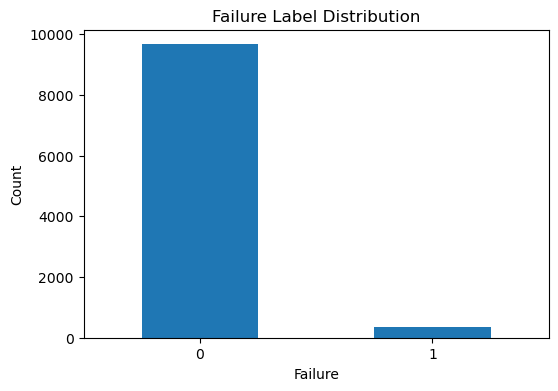

In [12]:
plt.figure(figsize=(6, 4))
failure_count.sort_index().plot(kind="bar")

plt.xlabel("Failure")
plt.ylabel("Count")
plt.title("Failure Label Distribution")
plt.xticks(rotation=0)

plt.savefig(FIGURE_DIR / "failure_label_distribution.png", bbox_inches="tight")
plt.show()

## 이진분류 target 분포 확인 결과

`failure` 컬럼의 분포를 확인한 결과, 정상 데이터가 대부분을 차지하고 고장 데이터는 상대적으로 적게 나타났다.

따라서 이 데이터는 클래스 불균형 문제가 존재한다.

이후 모델 평가에서는 단순 Accuracy만 사용하지 않고, Precision, Recall, F1-score, ROC-AUC를 함께 사용해야 한다.

특히 제조 설비 고장 예측에서는 실제 고장을 정상으로 예측하는 경우가 중요하므로 Recall과 F1-score를 함께 확인한다.

# 5. Feature / Target 분리

머신러닝 모델 학습을 위해 입력 변수인 Feature와 예측 대상인 Target을 분리한다.

Target 변수는 `failure` 컬럼이다.

모델 학습에서 제외할 컬럼은 다음과 같다.

- `udi`: 단순 식별자
- `product_id`: 제품 식별자
- `failure`: 정답 컬럼
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: 고장 유형을 나타내는 라벨성 컬럼

특히 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 발생 이후의 원인을 나타내는 컬럼이므로,  
고장 여부를 예측하는 모델에 포함하면 데이터 누수가 발생할 수 있다.

In [13]:
drop_cols = [
    "udi",
    "product_id",
    "failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = df.drop(columns=drop_cols)
y = df["failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10000, 6)
y shape: (10000,)


,type,air_temp,process_temp,rot_speed,torque,tool_wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 범주형 변수 인코딩

`type` 컬럼은 제품 유형을 나타내는 범주형 변수이다.

머신러닝 모델은 문자열 데이터를 직접 학습할 수 없기 때문에,  
`type` 컬럼을 One-Hot Encoding 방식으로 변환한다.

In [14]:
X = pd.get_dummies(X, columns=["type"], drop_first=True)

X.head()

,air_temp,process_temp,rot_speed,torque,tool_wear,type_L,type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   air_temp      10000 non-null  float64
 1   process_temp  10000 non-null  float64
 2   rot_speed     10000 non-null  int64  
 3   torque        10000 non-null  float64
 4   tool_wear     10000 non-null  int64  
 5   type_L        10000 non-null  bool   
 6   type_M        10000 non-null  bool   
dtypes: bool(2), float64(3), int64(2)
memory usage: 410.3 KB


## Feature / Target 분리 결과

모델 학습에 사용할 Feature와 Target을 분리하였다.

식별자 컬럼인 `udi`, `product_id`는 제거하였고,  
정답 컬럼인 `failure`도 Feature에서 제외하였다.

또한 `TWF`, `HDF`, `PWF`, `OSF`, `RNF`는 고장 유형을 직접적으로 나타내는 라벨성 컬럼이므로  
데이터 누수를 방지하기 위해 모델 입력 변수에서 제외하였다.

범주형 변수인 `type`은 One-Hot Encoding을 적용하여 숫자형 변수로 변환하였다.

# 6. Train / Valid / Test Split

모델 학습과 평가를 위해 데이터를 train, valid, test로 분리한다.

분리 비율은 다음과 같다.

- train: 70%
- valid: 15%
- test: 15%

데이터가 정상과 고장의 비율이 크게 다른 불균형 데이터이므로,  
`stratify` 옵션을 사용하여 각 데이터셋의 클래스 비율을 비슷하게 유지한다.

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)
print("y_test:", y_test.shape)

X_train: (7000, 7)
X_valid: (1500, 7)
X_test: (1500, 7)
y_train: (7000,)
y_valid: (1500,)
y_test: (1500,)


In [18]:
print("Train target ratio")
print(y_train.value_counts(normalize=True) * 100)

print("\nValid target ratio")
print(y_valid.value_counts(normalize=True) * 100)

print("\nTest target ratio")
print(y_test.value_counts(normalize=True) * 100)

Train target ratio
failure
0    96.614286
1     3.385714
Name: proportion, dtype: float64

Valid target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64

Test target ratio
failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## 데이터 분리 결과

전체 데이터를 train, valid, test로 분리하였다.

train 데이터는 모델 학습에 사용하고,  
valid 데이터는 모델 비교와 선택에 사용하며,  
test 데이터는 최종 성능 평가에 사용한다.

Target 클래스 비율을 확인한 결과, train, valid, test 데이터셋에서 정상과 고장의 비율이 유사하게 유지되었다.

이는 `stratify` 옵션을 적용했기 때문이다.

# 7. 평가 함수 생성

여러 머신러닝 모델을 동일한 기준으로 비교하기 위해 평가 함수를 생성한다.

이번 프로젝트는 정상/고장을 예측하는 이진분류 문제이므로 다음 평가 지표를 사용한다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report

AI4I 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로,  
단순 Accuracy만으로 모델 성능을 판단하면 안 된다.

제조 설비 고장 예측에서는 실제 고장을 얼마나 잘 탐지하는지가 중요하므로  
Recall과 F1-score를 함께 확인한다.

## 평가 지표 해석 기준

각 평가 지표의 의미는 다음과 같다.

- Accuracy: 전체 데이터 중 맞게 예측한 비율
- Precision: 고장이라고 예측한 것 중 실제 고장인 비율
- Recall: 실제 고장 중 모델이 고장으로 잡아낸 비율
- F1-score: Precision과 Recall의 균형 지표
- ROC-AUC: 모델이 정상과 고장을 구분하는 전반적인 성능

불균형 데이터에서는 Accuracy가 높아도 실제 고장을 거의 잡지 못할 수 있다.  
따라서 본 프로젝트에서는 Accuracy뿐만 아니라 Recall, F1-score, ROC-AUC를 함께 확인한다.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [21]:
def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }
    
    return result

## 상세 평가 함수 생성

모델의 성능을 더 자세히 확인하기 위해 Confusion Matrix와 Classification Report를 출력하는 함수를 추가로 생성한다.

이 함수는 모델의 예측 결과를 확인할 때 사용한다.

In [22]:
def print_evaluation_report(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    
    print("Confusion Matrix")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))

## 평가 함수 생성 결과

모델별 성능을 동일한 기준으로 비교하기 위해 `evaluate_model()` 함수를 생성하였다.

`evaluate_model()` 함수는 모델, 입력 데이터, 실제 정답을 입력받아  
Accuracy, Precision, Recall, F1-score, ROC-AUC를 계산한다.

또한 `print_evaluation_report()` 함수를 추가로 생성하여  
Confusion Matrix와 Classification Report를 함께 확인할 수 있도록 하였다.

이후 단계에서는 모델을 학습한 뒤, 동일한 평가 함수를 사용하여 모델 성능을 비교한다.

# 8. Baseline 모델 - Logistic Regression

첫 번째 모델로 Logistic Regression을 사용한다.

Logistic Regression은 이진분류 문제에서 가장 기본적으로 사용되는 모델 중 하나이며,  
이후 RandomForest, XGBoost 같은 모델과 비교하기 위한 baseline 모델로 활용할 수 있다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로  
`class_weight="balanced"` 옵션을 적용한다.

또한 Logistic Regression은 변수의 스케일에 영향을 받을 수 있으므로  
`StandardScaler`를 함께 사용한다.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [24]:
log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [25]:
log_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [26]:
log_valid_result = evaluate_model(log_model, X_valid, y_valid)

log_valid_result

{'Accuracy': 0.8346666666666667,
 'Precision': 0.13653136531365315,
 'Recall': 0.7254901960784313,
 'F1': 0.22981366459627328,
 'ROC-AUC': 0.875018606476407}

In [27]:
print_evaluation_report(log_model, X_valid, y_valid)

Confusion Matrix
[[1215  234]
 [  14   37]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1449
           1       0.14      0.73      0.23        51

    accuracy                           0.83      1500
   macro avg       0.56      0.78      0.57      1500
weighted avg       0.96      0.83      0.88      1500

ROC-AUC: 0.875018606476407


## Logistic Regression 평가 결과

Logistic Regression 모델을 baseline 모델로 학습하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 약 0.835
- Precision: 약 0.137
- Recall: 약 0.725
- F1-score: 약 0.230
- ROC-AUC: 약 0.875

Confusion Matrix를 확인한 결과, 실제 고장 51개 중 37개를 고장으로 예측하였고, 14개는 정상으로 잘못 예측하였다.  
따라서 Logistic Regression 모델은 실제 고장을 비교적 많이 탐지하는 편이지만, 정상 데이터를 고장으로 잘못 예측하는 경우도 많았다.

특히 Precision이 낮고 Recall이 높은 결과가 나타났는데, 이는 `class_weight="balanced"` 옵션으로 인해 모델이 소수 클래스인 고장을 더 적극적으로 예측했기 때문으로 해석할 수 있다.

제조 설비 고장 예측에서는 고장을 놓치지 않는 것이 중요하므로 Recall이 높은 점은 긍정적이다.  
그러나 정상 설비를 고장으로 잘못 판단하는 경우가 많아 Precision과 F1-score는 낮게 나타났다.

ROC-AUC는 약 0.875로 나타나, 모델의 정상/고장 구분 능력은 baseline 모델로서 의미 있는 수준이라고 볼 수 있다.

이후 RandomForest 모델을 학습하여 Logistic Regression baseline과 성능을 비교한다.

# 9. RandomForest 모델

두 번째 모델로 RandomForest를 학습한다.

RandomForest는 여러 개의 Decision Tree를 결합한 앙상블 모델이다.  
비선형 관계를 학습할 수 있으며, 변수 중요도인 Feature Importance를 확인할 수 있다는 장점이 있다.

Logistic Regression과 달리 RandomForest는 변수 스케일에 크게 영향을 받지 않기 때문에 StandardScaler를 적용하지 않는다.

이번 데이터는 정상 데이터가 많고 고장 데이터가 적은 불균형 데이터이므로  
`class_weight="balanced"` 옵션을 적용한다.

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_valid_result = evaluate_model(rf_model, X_valid, y_valid)

rf_valid_result

{'Accuracy': 0.976,
 'Precision': 0.7777777777777778,
 'Recall': 0.4117647058823529,
 'F1': 0.5384615384615384,
 'ROC-AUC': 0.972705990608804}

In [32]:
print_evaluation_report(rf_model, X_valid, y_valid)

Confusion Matrix
[[1443    6]
 [  30   21]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.78      0.41      0.54        51

    accuracy                           0.98      1500
   macro avg       0.88      0.70      0.76      1500
weighted avg       0.97      0.98      0.97      1500

ROC-AUC: 0.972705990608804


## RandomForest 평가 결과

RandomForest 모델을 학습한 뒤 검증 데이터 기준으로 성능을 평가하였다.

검증 데이터 기준 성능은 다음과 같다.

- Accuracy: 약 0.976
- Precision: 약 0.778
- Recall: 약 0.412
- F1-score: 약 0.538
- ROC-AUC: 약 0.973

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1443개를 정상으로 정확히 예측하였고, 정상 데이터를 고장으로 잘못 예측한 경우는 6개였다.

반면 실제 고장 51개 중 21개를 고장으로 탐지하였고, 30개는 정상으로 잘못 예측하였다.

RandomForest는 고장이라고 예측한 경우의 신뢰도는 비교적 높게 나타났지만, 실제 고장을 놓치는 경우도 존재하였다.

따라서 제조 설비 고장 예측 관점에서는 Precision뿐만 아니라 Recall과 F1-score를 함께 고려해야 한다.

# 10. 모델 성능 비교

검증 데이터 기준으로 Logistic Regression baseline 모델과 RandomForest 모델의 성능을 비교한다.

비교 지표는 다음과 같다.

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

불균형 데이터에서는 Accuracy만으로 모델을 판단하기 어렵다.  
따라서 Precision, Recall, F1-score, ROC-AUC를 함께 비교한다.

In [33]:
print("Logistic Regression Result")
print(log_valid_result)

print("\nRandomForest Result")
print(rf_valid_result)

Logistic Regression Result
{'Accuracy': 0.8346666666666667, 'Precision': 0.13653136531365315, 'Recall': 0.7254901960784313, 'F1': 0.22981366459627328, 'ROC-AUC': 0.875018606476407}

RandomForest Result
{'Accuracy': 0.976, 'Precision': 0.7777777777777778, 'Recall': 0.4117647058823529, 'F1': 0.5384615384615384, 'ROC-AUC': 0.972705990608804}


In [34]:
model_results = []

log_result = log_valid_result.copy()
log_result["Model"] = "Logistic Regression"
model_results.append(log_result)

rf_result = rf_valid_result.copy()
rf_result["Model"] = "RandomForest"
model_results.append(rf_result)

result_df = pd.DataFrame(model_results)

result_df = result_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

result_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.834667,0.136531,0.725490,0.229814,0.875019
1,RandomForest,0.976000,0.777778,0.411765,0.538462,0.972706


In [35]:
result_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,RandomForest,0.976000,0.777778,0.411765,0.538462,0.972706
0,Logistic Regression,0.834667,0.136531,0.725490,0.229814,0.875019


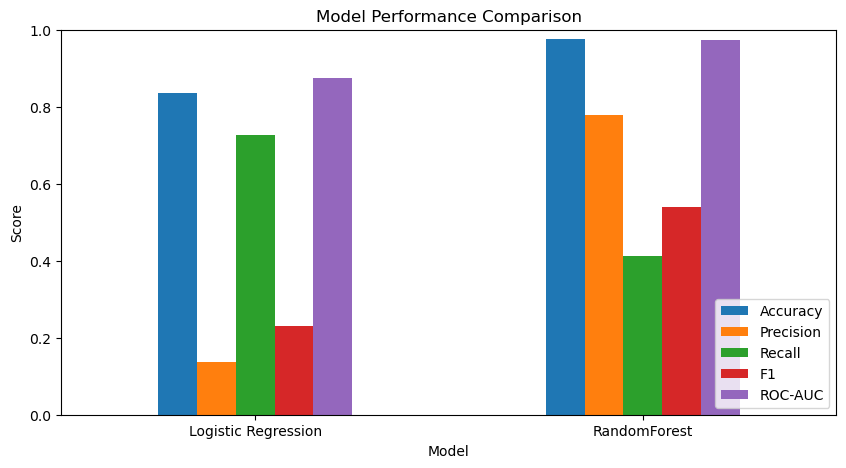

In [36]:
performance_plot_df = result_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

ax = performance_plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.savefig(FIGURE_DIR / "model_performance_comparison.png", bbox_inches="tight")
plt.show()

## 모델 성능 비교 그래프 해석

모델 성능 비교 그래프를 통해 Logistic Regression과 RandomForest의 성능 차이를 시각적으로 확인하였다.

RandomForest는 Accuracy, Precision, F1-score, ROC-AUC에서 Logistic Regression보다 높은 성능을 보였다.

반면 Logistic Regression은 Recall이 더 높게 나타났다.  
이는 Logistic Regression이 고장 데이터를 더 많이 탐지하는 방향으로 예측했기 때문이다.

하지만 Precision이 낮아 정상 데이터를 고장으로 잘못 예측하는 경우가 많았으므로,  
종합적인 성능은 RandomForest가 더 우수한 것으로 판단된다.

## 모델 성능 비교 결과

검증 데이터 기준으로 Logistic Regression baseline 모델과 RandomForest 모델의 성능을 비교하였다.

Logistic Regression 모델은 Accuracy 0.835, Precision 0.137, Recall 0.725, F1-score 0.230, ROC-AUC 0.875를 기록하였다.  
이 모델은 실제 고장의 약 72.5%를 탐지하여 Recall은 높았지만, 정상 데이터를 고장으로 잘못 예측하는 경우가 많아 Precision과 F1-score가 낮게 나타났다.

RandomForest 모델은 Accuracy 0.976, Precision 0.778, Recall 0.412, F1-score 0.538, ROC-AUC 0.973을 기록하였다.  
RandomForest는 Logistic Regression보다 Accuracy, Precision, F1-score, ROC-AUC가 높게 나타났다.

다만 RandomForest의 Recall은 0.412로 Logistic Regression보다 낮았다.  
이는 RandomForest가 고장이라고 예측한 경우의 신뢰도는 높지만, 실제 고장 중 일부를 정상으로 예측하는 경우가 있음을 의미한다.

제조 설비 고장 예측에서는 고장을 놓치지 않는 것도 중요하지만, 정상 설비를 고장으로 잘못 판단하는 오탐도 운영 비용에 영향을 줄 수 있다.  
따라서 Precision과 Recall의 균형을 함께 고려해야 한다.

현재 검증 데이터 기준으로는 F1-score와 ROC-AUC가 더 높은 RandomForest를 더 우수한 모델로 판단하였다.

# 11. 최종 모델 선택 및 Test 평가

검증 데이터 기준 모델 성능 비교 결과, RandomForest 모델이 Logistic Regression보다 F1-score와 ROC-AUC에서 더 높은 성능을 보였다.

따라서 본 프로젝트에서는 RandomForest를 최종 후보 모델로 선택한다.

이 단계에서는 아직 모델 선택 과정에 사용하지 않은 test 데이터를 사용하여 최종 성능을 평가한다.

- train 데이터: 모델 학습
- valid 데이터: 모델 비교 및 선택
- test 데이터: 최종 성능 평가

In [37]:
best_model = rf_model
best_model_name = "RandomForest"

best_model_name

'RandomForest'

In [38]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

In [39]:
test_result = evaluate_model(best_model, X_test, y_test)

test_result

{'Accuracy': 0.9786666666666667,
 'Precision': 0.9130434782608695,
 'Recall': 0.4117647058823529,
 'F1': 0.5675675675675675,
 'ROC-AUC': 0.9613391250219896}

In [40]:
print_evaluation_report(best_model, X_test, y_test)

Confusion Matrix
[[1447    2]
 [  30   21]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.91      0.41      0.57        51

    accuracy                           0.98      1500
   macro avg       0.95      0.71      0.78      1500
weighted avg       0.98      0.98      0.97      1500

ROC-AUC: 0.9613391250219896


In [41]:
test_result_df = pd.DataFrame([test_result])
test_result_df.insert(0, "Model", best_model_name)

test_result_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RandomForest,0.978667,0.913043,0.411765,0.567568,0.961339


In [42]:
cm = confusion_matrix(y_test, y_test_pred)

cm

array([[1447,    2],
       [  30,   21]])

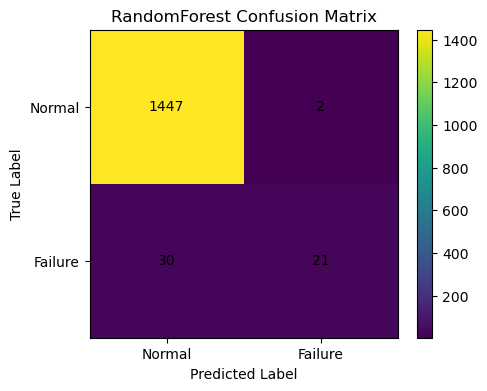

In [43]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)
plt.title("RandomForest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Normal", "Failure"])
plt.yticks([0, 1], ["Normal", "Failure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.savefig(FIGURE_DIR / "confusion_matrix_randomforest.png", bbox_inches="tight")
plt.show()

## Test 데이터 최종 평가 결과

검증 데이터 기준으로 가장 우수한 성능을 보인 RandomForest 모델을 최종 모델로 선택하였다.

최종 모델은 모델 학습과 검증 과정에 사용하지 않은 test 데이터에서 평가하였다.

Test 데이터 기준 성능은 다음과 같다.

- Accuracy: 0.979
- Precision: 0.913
- Recall: 0.412
- F1-score: 0.568
- ROC-AUC: 0.961

Confusion Matrix를 확인한 결과, 실제 정상 1449개 중 1447개를 정상으로 정확히 예측하였고, 정상 데이터를 고장으로 잘못 예측한 경우는 2개였다.

반면 실제 고장 51개 중 21개를 고장으로 탐지하였고, 30개는 정상으로 잘못 예측하였다.

RandomForest 모델은 고장이라고 예측한 경우 실제 고장일 가능성이 높아 Precision이 0.913으로 높게 나타났다.  
그러나 실제 고장 중 일부를 정상으로 예측하여 놓친 경우가 존재하므로 Recall은 0.412로 상대적으로 낮게 나타났다.

즉, 최종 모델은 정상 설비를 고장으로 잘못 판단하는 경우는 매우 적지만, 실제 고장을 놓치는 경우가 존재한다.

제조 설비 고장 예측에서는 실제 고장을 놓치지 않는 것도 중요하므로, 향후 threshold 조정, class_weight 조정, 하이퍼파라미터 튜닝 등을 통해 Recall을 개선할 필요가 있다.